In [1]:
%load_ext autoreload
%autoreload 2




import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ozy



   ___                                           _  _             
  /___\ ____ _   _  _ __ ___    __ _  _ __    __| |(_)  __ _  ___ 
 //  //|_  /| | | || '_ ` _ \  / _` || '_ \  / _` || | / _` |/ __|
/ \_//  / / | |_| || | | | | || (_| || | | || (_| || || (_| |\__ \
\___/  /___| \__, ||_| |_| |_| \__,_||_| |_| \__,_||_| \__,_||___/
             |___/                                                

   (C) 2021 F. Rodriguez Montero
   Version 0.2.dev1



In [2]:

gal_number = 2

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

gas_name = '*gas*_' + str(gal_number) + '.hdf5'

gas_files = []
for filename in glob.glob(os.path.join(directory, gas_name)):
    gas_files.append(filename)


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

stars_files = []
for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_number) + '.hdf5')):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_number) + '.hdf5')):
    dm_files.append(filename)

gas_filename = gas_files[0]
print(gas_filename)
star_filename = stars_files[0]
dm_filename = dm_files[0]


from dynamics import load_all_data

star_data, dm_data, gas_data, mass_multiplier, length_multiplier, time_multiplier = load_all_data(star_filename, dm_filename, gas_filename, ozy_file)


positions = np.column_stack((gas_data['x'], gas_data['y'], gas_data['z']))
velocities = np.column_stack((gas_data['vx'], gas_data['vy'], gas_data['vz']))
masses = gas_data['mass']

total_mass = np.sum(masses)

print('Total mass of the gas particles: ', total_mass)

print(velocities.shape)



/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/gas_gal_2.hdf5
Total mass of the gas particles:  57492952973.311646 Msun/kpc**3
(7842916, 3)


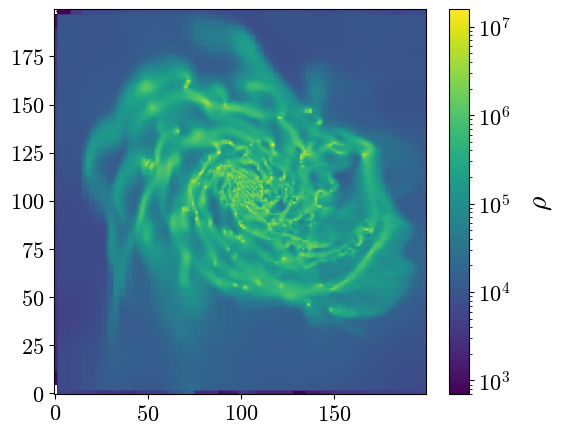

In [9]:
import importlib
import dynamics
importlib.reload(dynamics)



from dynamics import load_gas_data


positions ,masses, densities, velocities = load_gas_data(gas_filename, ozy_file)




13448
[-3.81740087e-06 -1.68546234e-06 -1.35148049e-06] Msun/(kpc**2*s)


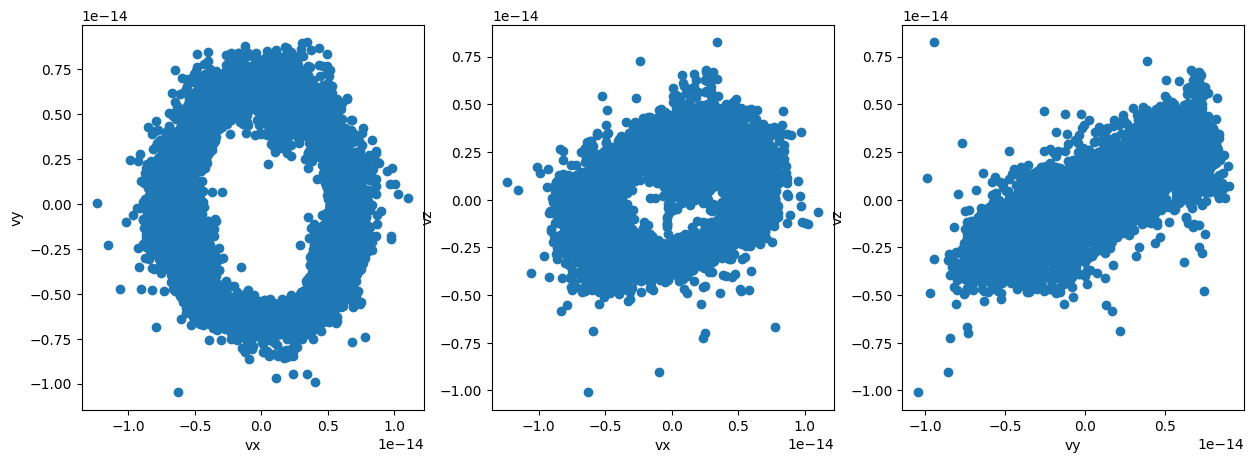

In [14]:
print(len(masses))


total_momentum = np.nansum(velocities * masses[:, np.newaxis], axis=0)

print(total_momentum)

fig,ax = plt.subplots(1,3 , figsize=(15,5))


ax[0].scatter(velocities[:,0], velocities[:,1])
ax[0].set_xlabel('vx')
ax[0].set_ylabel('vy')
ax[1].scatter(velocities[:,0], velocities[:,2])
ax[1].set_xlabel('vx')
ax[1].set_ylabel('vz')
ax[2].scatter(velocities[:,1], velocities[:,2])
ax[2].set_xlabel('vy')
ax[2].set_ylabel('vz')

plt.show()

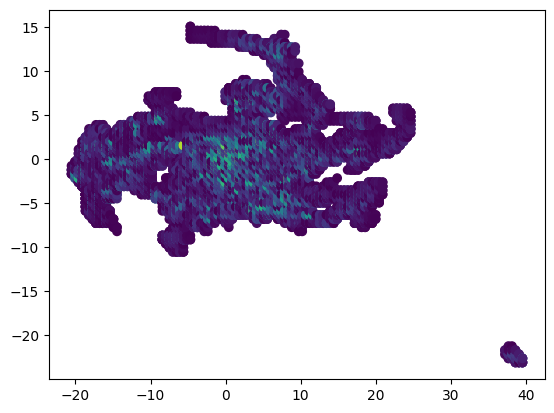

In [15]:
plt.scatter(positions[:,0], positions[:,2], c = np.log10(masses))
plt.show()

In [16]:
from dynamics import create_rotation_matrix

rot_matrix = create_rotation_matrix(velocities, positions, masses, False)

[[ 0.90770292 -0.40959737 -0.09113398]
 [-0.40959737 -0.81771738 -0.40443576]
 [ 0.09113398  0.40443576 -0.91001446]]


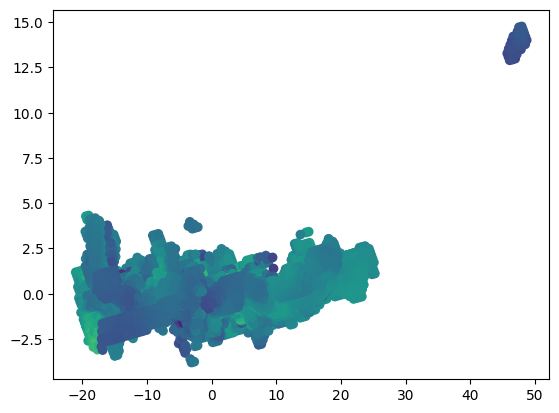

In [17]:
velocities_rot= np.dot(rot_matrix, velocities[:][:].T).T
positions_rot = np.dot(rot_matrix, positions[:][:].T).T

velocities_rot_abs = np.linalg.norm(velocities_rot, axis=1)


plt.scatter(positions_rot[:,0], positions_rot[:,2], c = np.log10(velocities_rot_abs))
plt.show()


In [18]:
angular_momenta = np.cross(positions, velocities) * masses[:, np.newaxis]
total_angular_momentum = np.sum(angular_momenta, axis=0)

total_angular_momentum_unit_v = total_angular_momentum/np.linalg.norm(total_angular_momentum)

print('Total angular momentum: ', total_angular_momentum_unit_v)

momentum = velocities_rot * masses[:, np.newaxis]
angular_momentum = np.cross(positions_rot, momentum)
print(angular_momentum.shape)
total_angular_momentum_rot = np.sum(angular_momentum, axis=0)
total_angular_momentum_rot_unit_v = total_angular_momentum_rot/np.linalg.norm(total_angular_momentum_rot)

print('Total angular momentum: ', total_angular_momentum_rot_unit_v)

Total angular momentum:  [ 0.09113398  0.40443576 -0.91001446] dimensionless
(13448, 3)
Total angular momentum:  [9.26890622e-16 1.91040310e-15 1.00000000e+00] dimensionless


<Figure size 640x480 with 0 Axes>

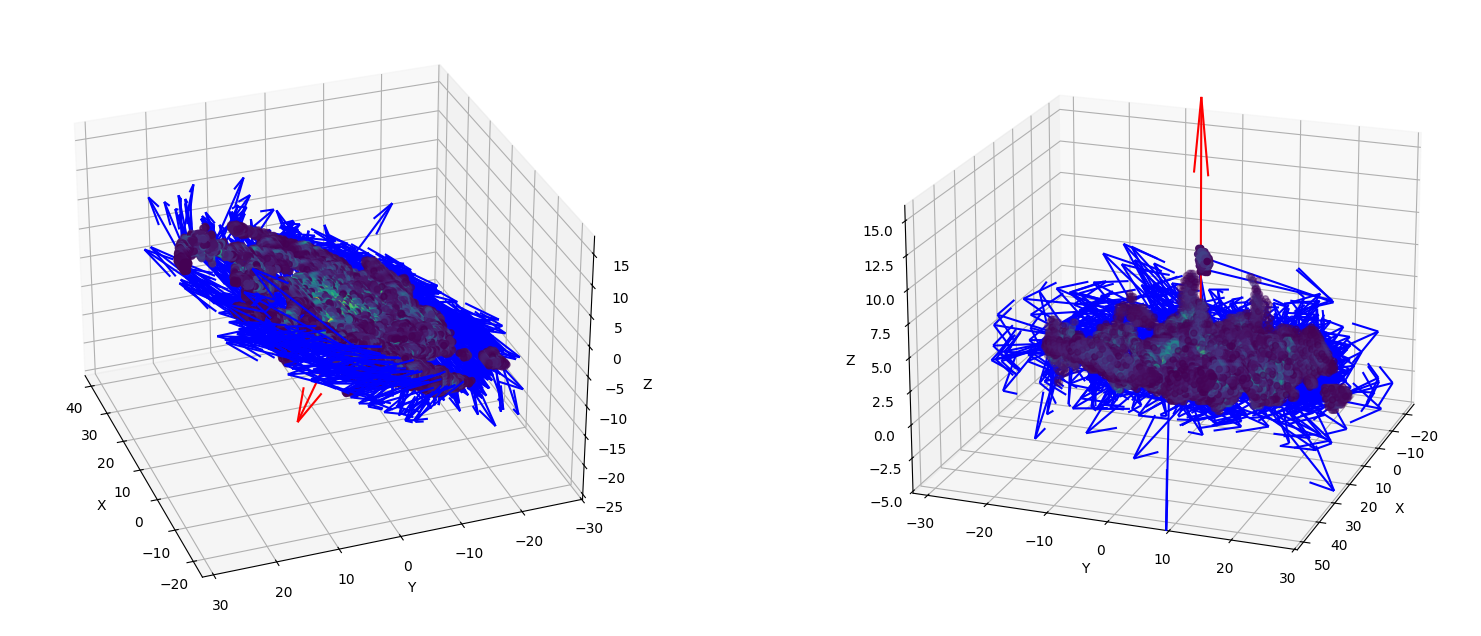

In [19]:
fig = plt.figure()
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(20, 8))


ax1.scatter(positions[:,0], positions[:,1], positions[:,2], c = np.log10(masses))

ax1.quiver(0, 0, 0, total_angular_momentum_unit_v[0]*20, total_angular_momentum_unit_v[1]*20, total_angular_momentum_unit_v[2]*20, color='r')

for i in range(0, len(velocities_rot), 30):
    rotated_vel = velocities_rot[i]/np.linalg.norm(velocities_rot[i])
    vel = velocities[i]/np.linalg.norm(velocities[i])
    rotated_pos = positions_rot[i]
    pos = positions[i]
    ax1.quiver(pos[0], pos[1], pos[2], vel[0]*20, vel[1]*20, vel[2]*20, color='b')
    ax2.quiver(rotated_pos[0], rotated_pos[1], rotated_pos[2], rotated_vel[0]*20, rotated_vel[1]*20, rotated_vel[2]*20, color='b')


ax2.scatter(positions_rot[:,0], positions_rot[:,1], positions_rot[:,2], c = np.log10(masses))

ax2.quiver(0, 0, 0, total_angular_momentum_rot_unit_v[0]*20, total_angular_momentum_rot_unit_v[1]*20, total_angular_momentum_rot_unit_v[2]*20, color='r')
ax2.view_init(elev=20, azim=20)
ax1.view_init( azim=160)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')


plt.show()




In [20]:
print(velocities.shape)

velocities_plot = np.sum(velocities, axis=0)


print(velocities_plot.shape)

(13448, 3)
(3,)


In [21]:
centroid = np.average(positions, axis=0, weights=masses)

# Compute the mass-weighted inertia tensor
I = np.zeros((3, 3))
for i in range(len(masses)):
    r = positions[i]
    m = masses[i]
    I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(I)

print(eigenvalues)

# The eigenvector corresponding to the largest eigenvalue is the normal to the plane
plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

# Plane equation: n.r = d
A, B, C = plane_normal
D = -np.dot(plane_normal, centroid)

print(f"Plane equation: {A:.4f}x + {B:.4f}y + {C:.4f}z + {D:.4f} = 0")

[1.42915256e+12 1.60110399e+12 3.00480266e+12] Msun/kpc**3
Plane equation: -0.0696x + -0.4154y + 0.9070z + -0.0000 dimensionless = 0


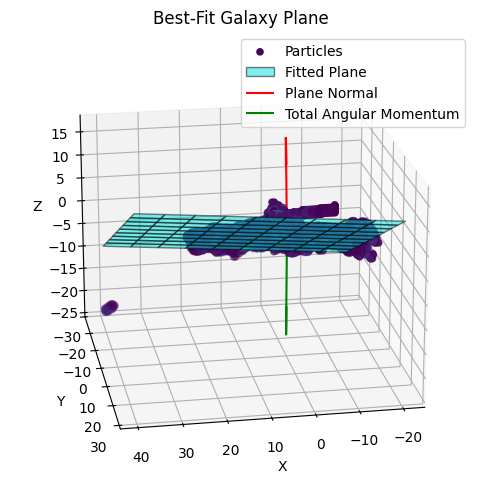

In [22]:
# Generate grid for the plane
x_vals = np.linspace(min(positions[:, 0]), max(positions[:, 0]), 10)
y_vals = np.linspace(min(positions[:, 1]), max(positions[:, 1]), 10)
X, Y = np.meshgrid(x_vals, y_vals)

# Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
Z = (-A * X - B * Y - D) / C

# Plot 3D points and the best-fit plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of particles
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=np.log10(masses), marker='o', label="Particles")

# Plot the plane
ax.plot_surface(X, Y, Z, alpha=0.5, color='cyan', edgecolor='k', label="Fitted Plane")

plane_normal = plane_normal/np.linalg.norm(plane_normal)
ax.quiver(0, 0, 0, plane_normal[0]*20, plane_normal[1]*20, plane_normal[2]*20, color='r', label="Plane Normal")

ax.quiver(0, 0, 0, total_angular_momentum_unit_v[0]*20, total_angular_momentum_unit_v[1]*20, total_angular_momentum_unit_v[2]*20, color='g', label="Total Angular Momentum")


ax.view_init(elev=20, azim=80)
# Labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Best-Fit Galaxy Plane")
plt.legend()
plt.show()

[-0.03678008  0.03537242 -0.04542887 ...  0.10847394  0.16847302
  0.12487175] dimensionless


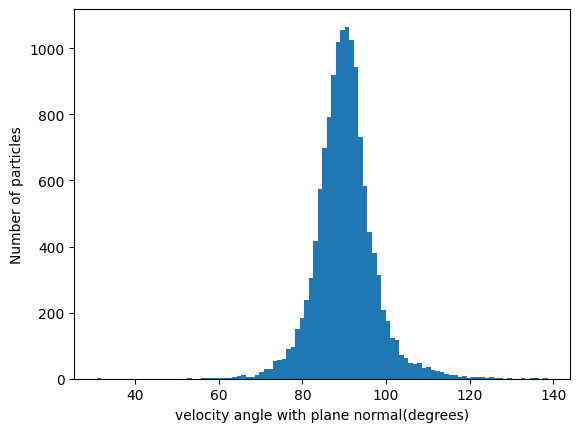

In [23]:
#Angle between each particles velocity and normal to the plane

#cos(theta) = v.n / |v||n|

cos_theta = np.dot(velocities, plane_normal)/(np.linalg.norm(velocities, axis=1)*np.linalg.norm(plane_normal))

print(cos_theta)

theta = np.arccos(cos_theta)/2/np.pi*360

plt.hist(theta, bins=100)
plt.xlabel('velocity angle with plane normal(degrees)')
plt.ylabel('Number of particles')
plt.show()

In [24]:
v1 = plane_normal
v2 = np.array([0,0,1])


cos = np.dot(v1, v2)
cross = np.cross(v1, v2)
sin = np.sum(cross**2)**0.5
cross = cross/sin
rotation_matrix = np.array([[cos + cross[0]**2*(1-cos), cross[0]*cross[1]*(1-cos) - cross[2]*sin, cross[0]*cross[2]*(1-cos) + cross[1]*sin],
                            [cross[1]*cross[0]*(1-cos) + cross[2]*sin, cos + cross[1]**2*(1-cos), cross[1]*cross[2]*(1-cos) - cross[0]*sin],
                            [cross[2]*cross[0]*(1-cos) - cross[1]*sin, cross[2]*cross[1]*(1-cos) + cross[0]*sin, cos + cross[2]**2*(1-cos)]])
#Rotation matrix found from wikipedia


print(rotation_matrix)
    
plane_normal_rotated = np.dot(rotation_matrix, plane_normal)

print(plane_normal_rotated)

positions_rotated = np.dot(rotation_matrix, positions.T).T
velocities_rotated = np.dot(rotation_matrix, velocities.T).T

[[ 0.99745761 -0.01516904  0.06962908]
 [-0.01516904  0.9094945   0.4154391 ]
 [-0.06962908 -0.4154391   0.90695212]]
[ 7.30777721e-18 -2.34151056e-17  1.00000000e+00]


<Figure size 640x480 with 0 Axes>

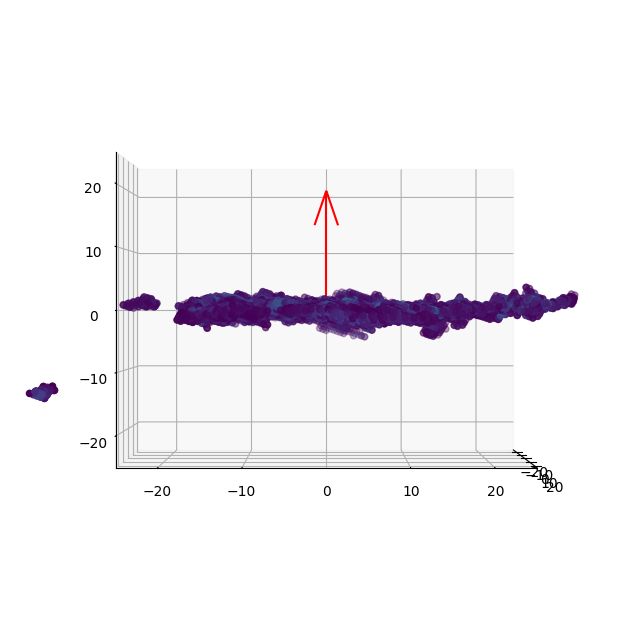

In [25]:

fig = plt.figure()
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(20, 8))


ax.scatter(positions_rotated[:,0], positions_rotated[:,1], positions_rotated[:,2], c = np.log10(masses))

ax.quiver(0, 0, 0, plane_normal_rotated[0]*20, plane_normal_rotated[1]*20, plane_normal_rotated[2]*20, color='r')

ax.view_init(elev=0, azim=0)

ax.set_xlim(-25,25)
ax.set_ylim(-25,25)
ax.set_zlim(-25,25)

plt.show()


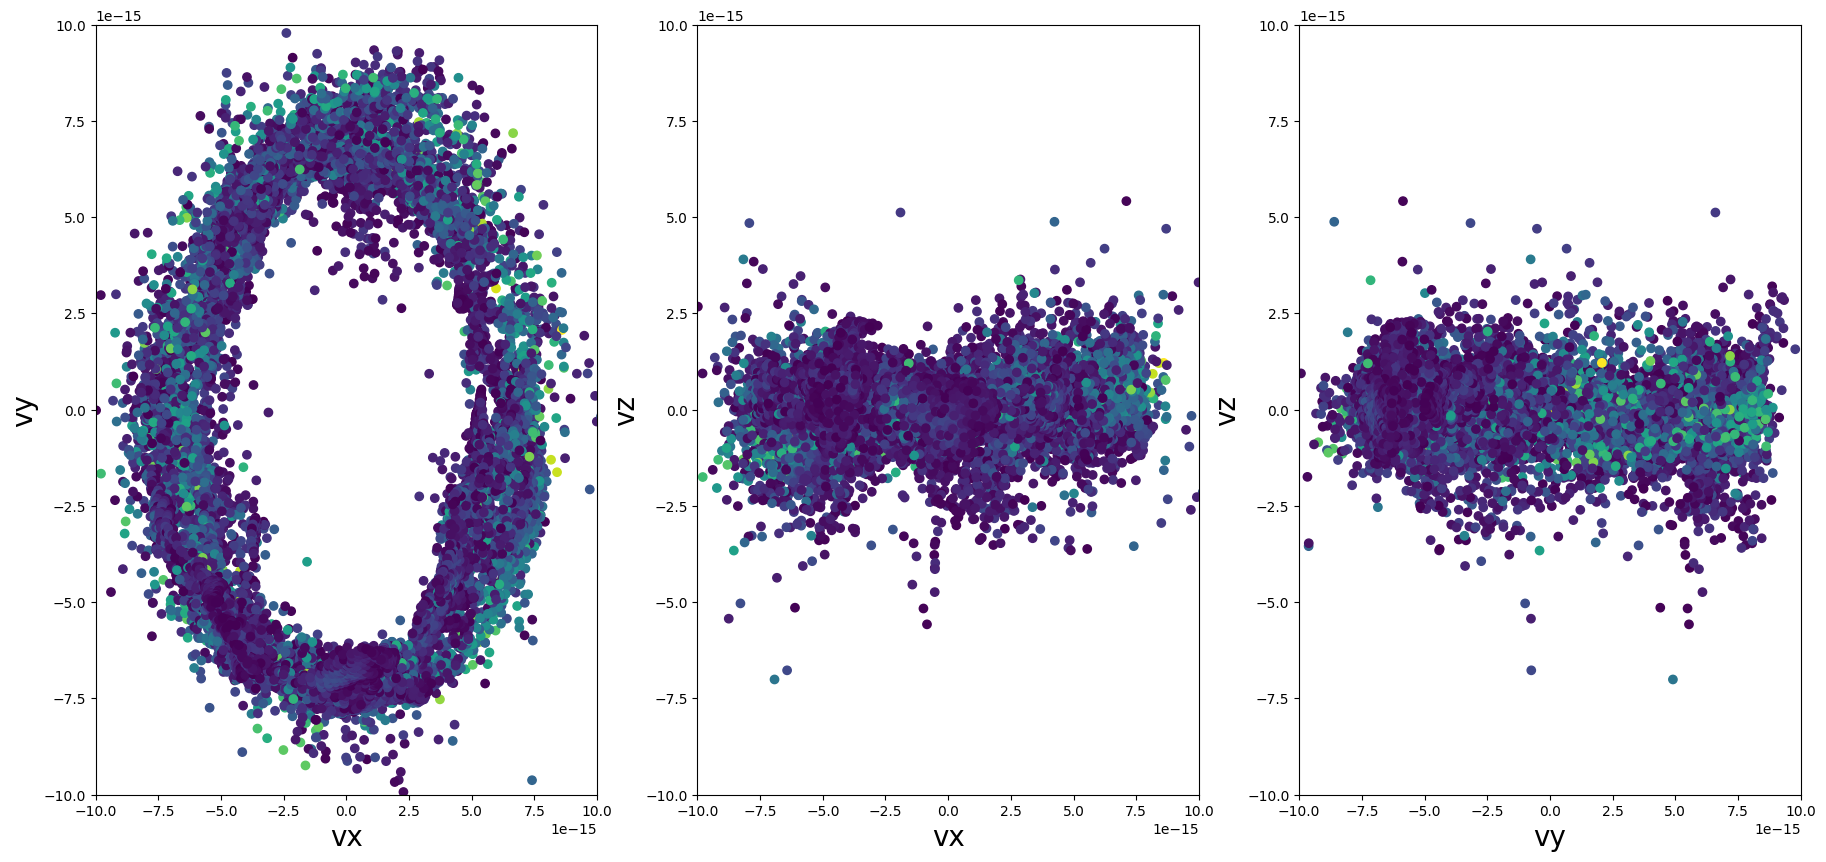

In [26]:
fig, ax = plt.subplots(1, 3, figsize = (22,10))

ax[0].scatter(velocities_rotated[:,0], velocities_rotated[:,1], c = np.log10(masses))
ax[0].set_xlabel('vx', fontsize=20)
ax[0].set_ylabel('vy', fontsize=20)
ax[0].set_xlim(-10e-15, 10e-15)
ax[0].set_ylim(-10e-15, 10e-15)

ax[1].scatter(velocities_rotated[:,0], velocities_rotated[:,2], c = np.log10(masses))
ax[1].set_xlabel('vx', fontsize=20)
ax[1].set_ylabel('vz', fontsize=20)
ax[1].set_xlim(-10e-15, 10e-15)
ax[1].set_ylim(-10e-15, 10e-15)

ax[2].scatter(velocities_rotated[:,1], velocities_rotated[:,2], c = np.log10(masses))
ax[2].set_xlabel('vy', fontsize=20)
ax[2].set_ylabel('vz', fontsize=20)
ax[2].set_xlim(-10e-15, 10e-15)
ax[2].set_ylim(-10e-15, 10e-15)


plt.show()

                                        

In [28]:

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]


from dynamics import load_gas_data

angles = []

for i in range(1, 21):

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

    gas_name = '*gas*_' + str(i) + '.hdf5'

    gas_files = []
    for filename in glob.glob(os.path.join(directory, gas_name)):
        gas_files.append(filename)


    gas_filename = gas_files[0]

    print(gas_filename)

    positions, masses, densities, velocities = load_gas_data(gas_filename, ozy_file)

    if len(masses) == 0:
        continue


    angular_momenta = np.cross(positions, velocities) * masses[:, np.newaxis]
    total_angular_momentum = np.sum(angular_momenta, axis=0)

    total_angular_momentum_unit_v = total_angular_momentum/np.linalg.norm(total_angular_momentum)


    centroid = np.average(positions, axis=0, weights=masses)

    # Compute the mass-weighted inertia tensor
    I = np.zeros((3, 3))
    for i in range(len(masses)):
        r = positions[i]
        m = masses[i]
        I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



    # Compute eigenvectors and eigenvalues
    eigenvalues, eigenvectors = np.linalg.eigh(I)


    # The eigenvector corresponding to the largest eigenvalue is the normal to the plane
    plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

    # Plane equation: n.r = d
    A, B, C = plane_normal
    D = -np.dot(plane_normal, centroid)


    # Generate grid for the plane
    x_vals = np.linspace(min(positions[:, 0]), max(positions[:, 0]), 10)
    y_vals = np.linspace(min(positions[:, 1]), max(positions[:, 1]), 10)
    X, Y = np.meshgrid(x_vals, y_vals)

    # Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
    Z = (-A * X - B * Y - D) / C

    plane_normal = plane_normal/np.linalg.norm(plane_normal)

    cos_theta = np.dot(total_angular_momentum_unit_v, plane_normal)/(np.linalg.norm(total_angular_momentum_unit_v)*np.linalg.norm(plane_normal))

    theta = np.arccos(cos_theta)/2/np.pi*360

    angles.append(theta)

/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/gas_gal_1.hdf5


KeyboardInterrupt: 

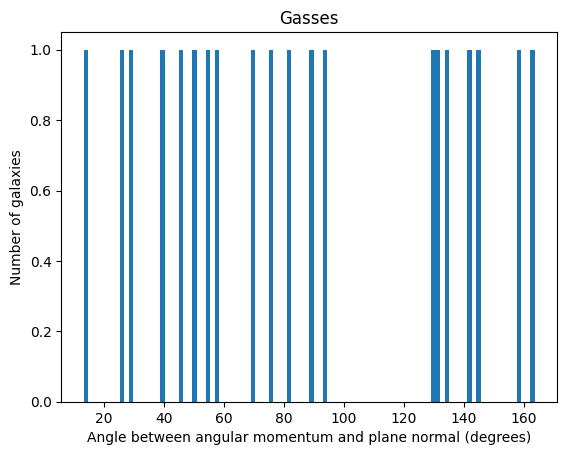

In [ ]:
plt.hist(angles, bins=100)
plt.xlabel('Angle between angular momentum and plane normal (degrees)')
plt.ylabel('Number of galaxies')
plt.title('Gasses')
plt.show()

In [29]:

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

stars_files = []
for filename in glob.glob(os.path.join(directory, '*star*_1.hdf5')):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, '*dm*_1.hdf5')):
    dm_files.append(filename)


from dynamics import load_data


filename = stars_files[0]
dm_filename = dm_files[0]

print(filename)

star_data, dm_data, mass_multiplier, length_multiplier, time_multiplier = load_data(filename, dm_filename, ozy_file)

xdata = star_data['x']
ydata = star_data['y']
zdata = star_data['z']

vxdata = star_data['vx']
vydata = star_data['vy']
vzdata = star_data['vz']

masses = star_data['mass']

positions = np.column_stack((xdata, ydata, zdata))

velocities = np.column_stack((vxdata, vydata, vzdata))

angular_momenta = np.cross(positions, velocities) * masses[:, np.newaxis]
total_angular_momentum = np.sum(angular_momenta, axis=0)

total_angular_momentum_unit_v = total_angular_momentum/np.linalg.norm(total_angular_momentum)

print('Total angular momentum: ', total_angular_momentum_unit_v)


centroid = np.average(positions, axis=0, weights=masses)

# Compute the mass-weighted inertia tensor
I = np.zeros((3, 3))
for i in range(0, len(masses), 1000):
    r = positions[i]
    m = masses[i]
    I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(I)


# The eigenvector corresponding to the largest eigenvalue is the normal to the plane
plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

# Plane equation: n.r = d
A, B, C = plane_normal
D = -np.dot(plane_normal, centroid)


# Generate grid for the plane
x_vals = np.linspace(min(positions[:, 0]), max(positions[:, 0]), 10)
y_vals = np.linspace(min(positions[:, 1]), max(positions[:, 1]), 10)
X, Y = np.meshgrid(x_vals, y_vals)

# Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
Z = (-A * X - B * Y - D) / C

plane_normal = plane_normal/np.linalg.norm(plane_normal)

v1 = plane_normal
v2 = np.array([0,0,1])


cos = np.dot(v1, v2)
cross = np.cross(v1, v2)
sin = np.sum(cross**2)**0.5
cross = cross/sin
rotation_matrix = np.array([[cos + cross[0]**2*(1-cos), cross[0]*cross[1]*(1-cos) - cross[2]*sin, cross[0]*cross[2]*(1-cos) + cross[1]*sin],
                            [cross[1]*cross[0]*(1-cos) + cross[2]*sin, cos + cross[1]**2*(1-cos), cross[1]*cross[2]*(1-cos) - cross[0]*sin],
                            [cross[2]*cross[0]*(1-cos) - cross[1]*sin, cross[2]*cross[1]*(1-cos) + cross[0]*sin, cos + cross[2]**2*(1-cos)]])
#Rotation matrix found from wikipedia


print(rotation_matrix)
    
plane_normal_rotated = np.dot(rotation_matrix, plane_normal)

print(plane_normal_rotated)

positions_rotated = np.dot(rotation_matrix, positions.T).T
velocities_rotated = np.dot(rotation_matrix, velocities.T).T






/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_1.hdf5
6232734
1175563
Total angular momentum:  [ 0.10098224  0.42618962 -0.89897998] dimensionless
[[ 9.99991713e-01  7.97973872e-04 -3.99202601e-03]
 [ 7.97973872e-04  9.23157140e-01  3.84421979e-01]
 [ 3.99202601e-03 -3.84421979e-01  9.23148854e-01]]
[-2.22268153e-19 -3.09406181e-17  1.00000000e+00]


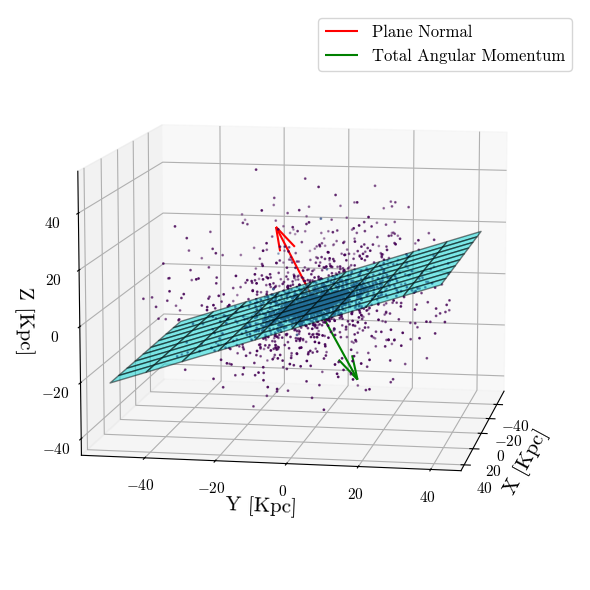

<Figure size 640x480 with 0 Axes>

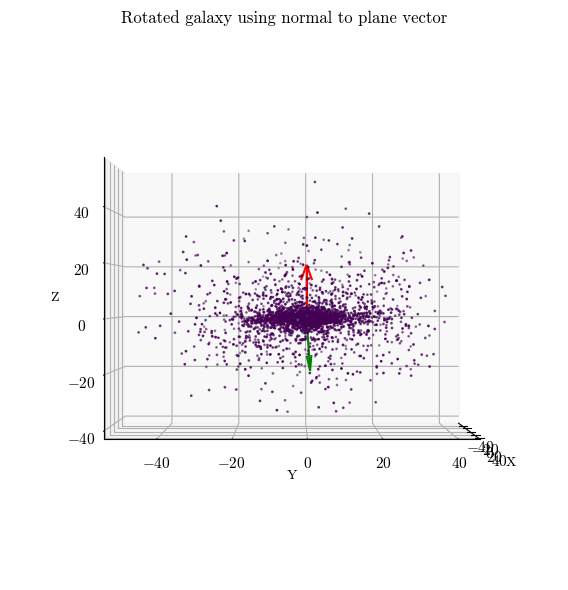

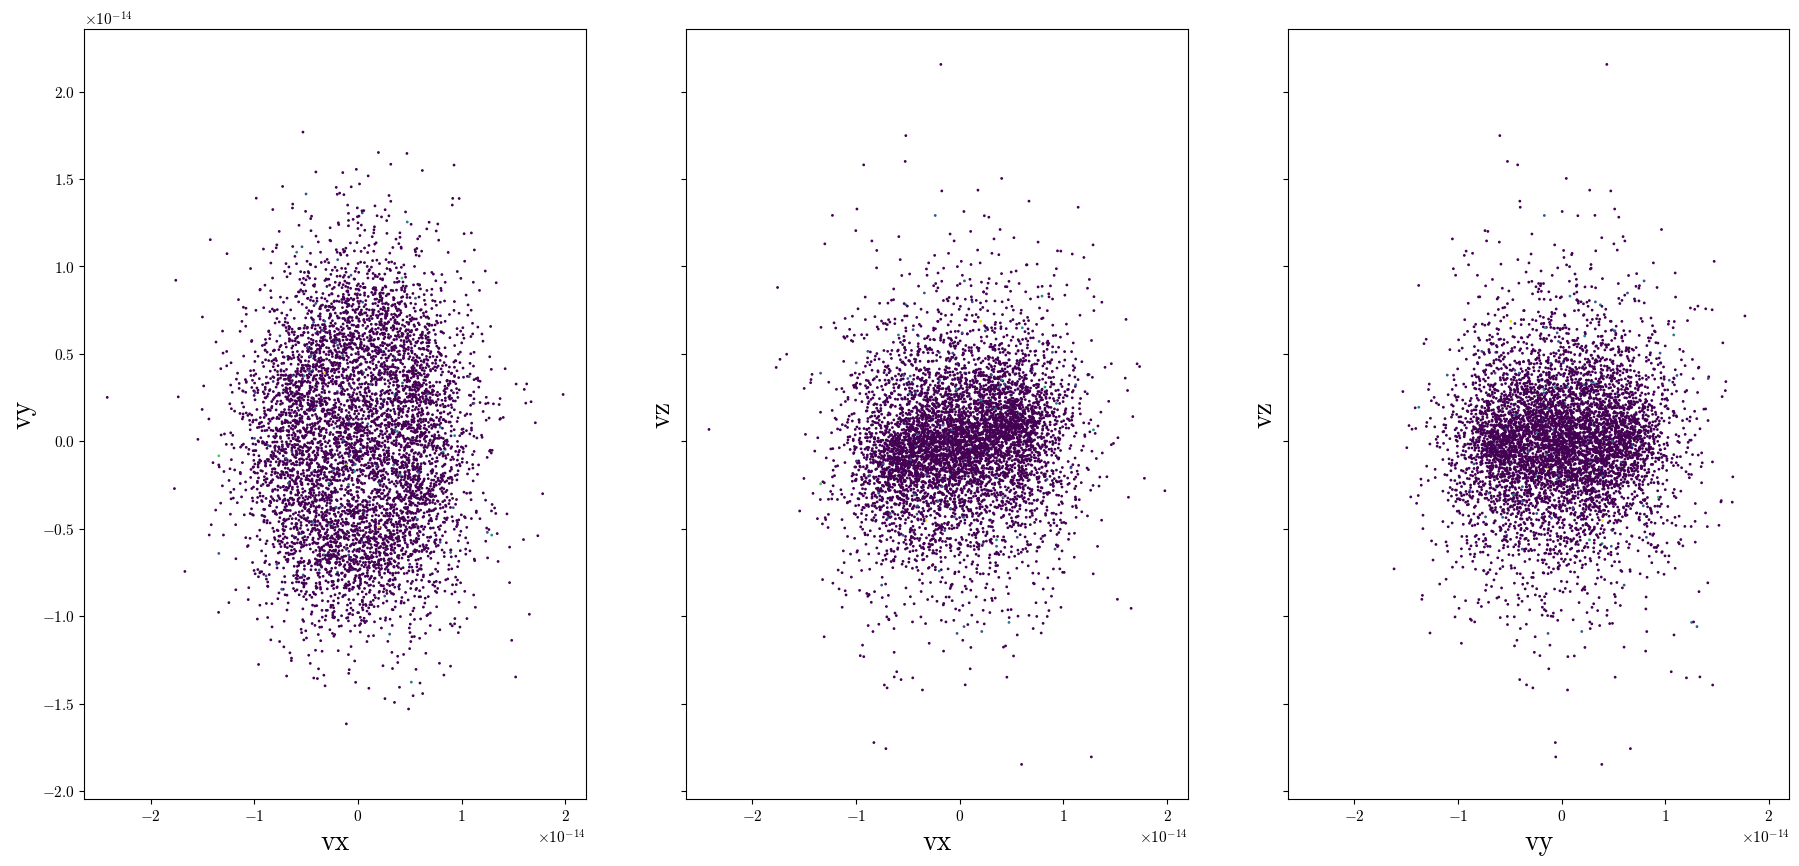

Angle between angular momentum and plane normal:  173.3766619451641


In [30]:
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 11   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 11   # Increase y-axis tick font size


# Plot 3D points and the best-fit plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of particles
ax.scatter(positions[:, 0][::1000], positions[:, 1][::1000], positions[:, 2][::1000], c=np.log10(masses[::1000]), marker='o', s = 1)

# Plot the plane
ax.plot_surface(X, Y, Z, alpha=0.5, color='cyan', edgecolor='k')

plane_normal = plane_normal/np.linalg.norm(plane_normal)
ax.quiver(0, 0, 0, plane_normal[0]*30, plane_normal[1]*30, plane_normal[2]*30, color='r', label="Plane Normal")

ax.quiver(0, 0, 0, total_angular_momentum_unit_v[0]*30, total_angular_momentum_unit_v[1]*30, total_angular_momentum_unit_v[2]*30, color='g', label="Total Angular Momentum")


ax.view_init(elev=10, azim=10)
# Labels and legend
ax.set_xlabel('X [Kpc]', fontsize = 15)
ax.set_ylabel('Y [Kpc]', fontsize = 15)
ax.set_zlabel('Z [Kpc]', fontsize = 15)
#ax.set_title("Best-Fit Galaxy Plane")
plt.tight_layout()
plt.legend(prop = {'size': 12})
plt.show()


fig = plt.figure()
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 6))


ax.scatter(positions_rotated[:,0][::1000], positions_rotated[:,1][::1000], positions_rotated[:,2][::1000], c = np.log10(masses[::1000]), s = 1)

ax.view_init(elev=0, azim=0)

ax.quiver(0, 0, 0, plane_normal_rotated[0]*20, plane_normal_rotated[1]*20, plane_normal_rotated[2]*20, color='r')

total_angular_momentum_rotated_unit_v = np.dot(rotation_matrix, total_angular_momentum_unit_v)

ax.quiver(0, 0, 0, total_angular_momentum_rotated_unit_v[0]*20, total_angular_momentum_rotated_unit_v[1]*20, total_angular_momentum_rotated_unit_v[2]*20, color='g', label="Total Angular Momentum")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_title('Rotated galaxy using normal to plane vector')

plt.tight_layout()

plt.show()

fig, ax = plt.subplots(1, 3, figsize = (22,10), sharey = True, sharex = True)

ax[0].scatter(velocities_rotated[:,0][::1000], velocities_rotated[:,1][::1000], c = np.log10(masses[::1000]), s = 1)
ax[0].set_xlabel('vx', fontsize=20)
ax[0].set_ylabel('vy', fontsize=20)


ax[1].scatter(velocities_rotated[:,0][::1000], velocities_rotated[:,2][::1000], c = np.log10(masses[::1000]), s = 1)
ax[1].set_xlabel('vx', fontsize=20)
ax[1].set_ylabel('vz', fontsize=20)


ax[2].scatter(velocities_rotated[:,1][::1000], velocities_rotated[:,2][::1000], c = np.log10(masses[::1000]), s = 1)
ax[2].set_xlabel('vy', fontsize=20)
ax[2].set_ylabel('vz', fontsize=20)



plt.show()


cos_theta = np.dot(total_angular_momentum_unit_v, plane_normal)/(np.linalg.norm(total_angular_momentum_unit_v)*np.linalg.norm(plane_normal))

theta = np.arccos(cos_theta)/2/np.pi*360

print('Angle between angular momentum and plane normal: ', theta)

In [2]:
star_angles_csv = pd.read_csv('/mnt/users/darnej/MPhys/angles_stars_files.csv')

angles_stars = star_angles_csv['angle']


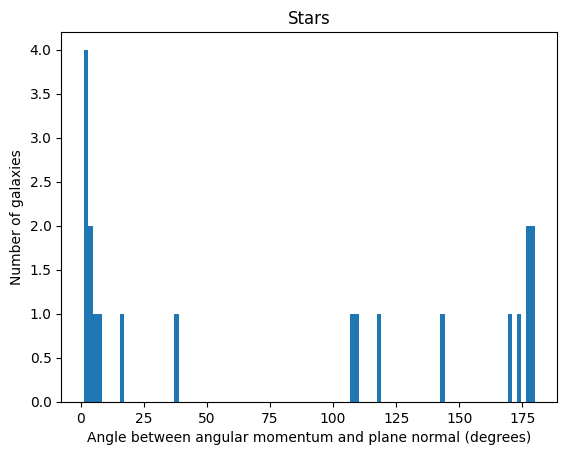

In [3]:
plt.hist(angles_stars, bins=100)
plt.xlabel('Angle between angular momentum and plane normal (degrees)')
plt.ylabel('Number of galaxies')
plt.title('Stars')
plt.show()

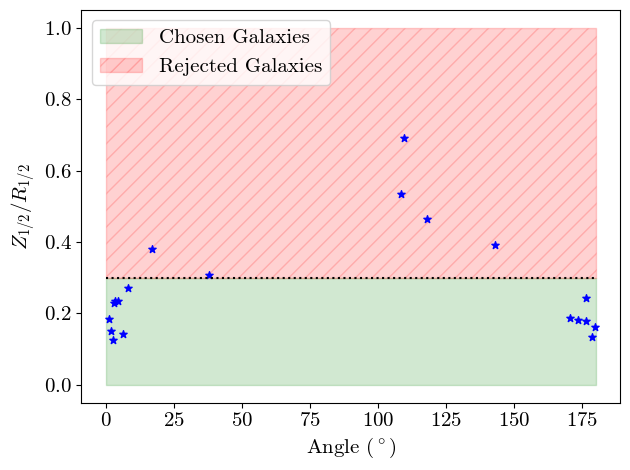

In [26]:
dataframe_csv = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 15   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 15   # Increase y-axis tick font size

ratios = dataframe_csv['ratio']

ratios = ratios[0:20]

x = np.linspace(0, 180, 100)
y = 0.3*np.ones(100)



plt.plot(x, y, color = 'black', linestyle='dotted')
plt.fill_between(x, 0, 0.3, color='green', alpha=0.18, label = 'Chosen Galaxies')
plt.fill_between(x, 0.3, 1, color='red', alpha=0.18, label = 'Rejected Galaxies', hatch = '//')


plt.scatter(angles_stars, ratios, marker = '*', color = 'blue', s = 30)
plt.xlabel('Angle ($^\circ$)', fontsize = 15)
plt.ylabel('$Z_{1/2}/R_{1/2}$', fontsize = 15)
plt.legend(loc = 'upper left', prop = {'size': 15})
plt.tight_layout()
plt.show()

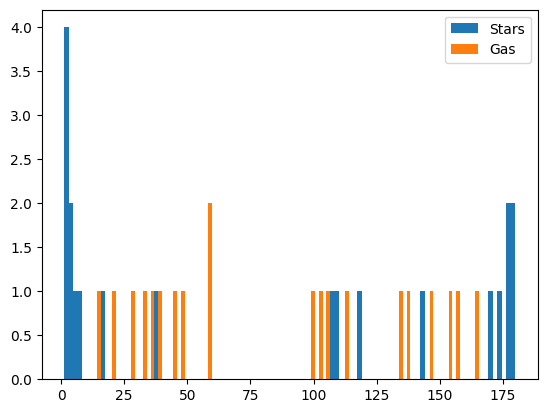

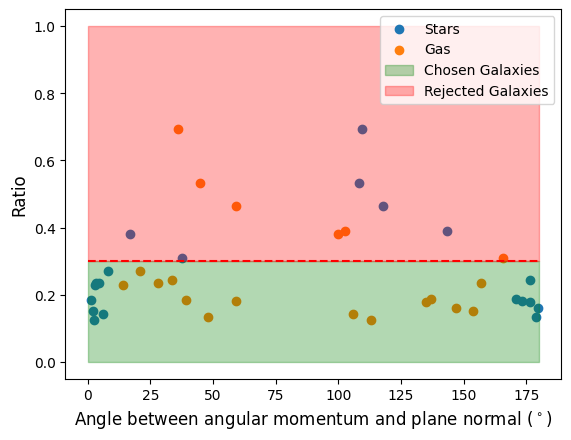

In [ ]:
star_angles_csv = pd.read_csv('/mnt/users/darnej/MPhys/angles_stars_files.csv')
gas_angles_csv = pd.read_csv('/mnt/users/darnej/MPhys/angles_gas_files.csv')

angles_stars = star_angles_csv['angle']
angles_gas = gas_angles_csv['angle']

plt.hist(angles_stars, bins=100, label = 'Stars')

plt.hist(angles_gas, bins=100, label = 'Gas')
plt.legend()
plt.show()

dataframe_csv = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')
ratio = dataframe_csv['ratio']

ratio = ratio[0:20]

x = np.linspace(0, 180, 100)
y = 0.3*np.ones(100)

plt.scatter(angles_stars, ratio, label = 'Stars')
plt.scatter(angles_gas, ratio, label = 'Gas')
plt.plot(x, y, color = 'r', linestyle='--')
plt.fill_between(x, 0, 0.3, color='green', alpha=0.3, label = 'Chosen Galaxies')
plt.fill_between(x, 0.3, 1, color='red', alpha=0.3, label = 'Rejected Galaxies')
plt.legend(loc = 'upper right')
plt.xlabel('Angle between angular momentum and plane normal ($^\circ$)', fontsize = 12)
plt.ylabel('Ratio', fontsize = 12)
plt.show()




/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/gas_gal_161.hdf5
Total mass of the gas particles:  2256500946.2307453 Msun/kpc**3


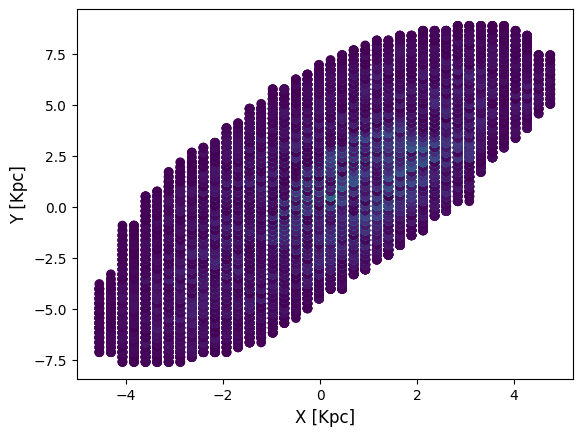

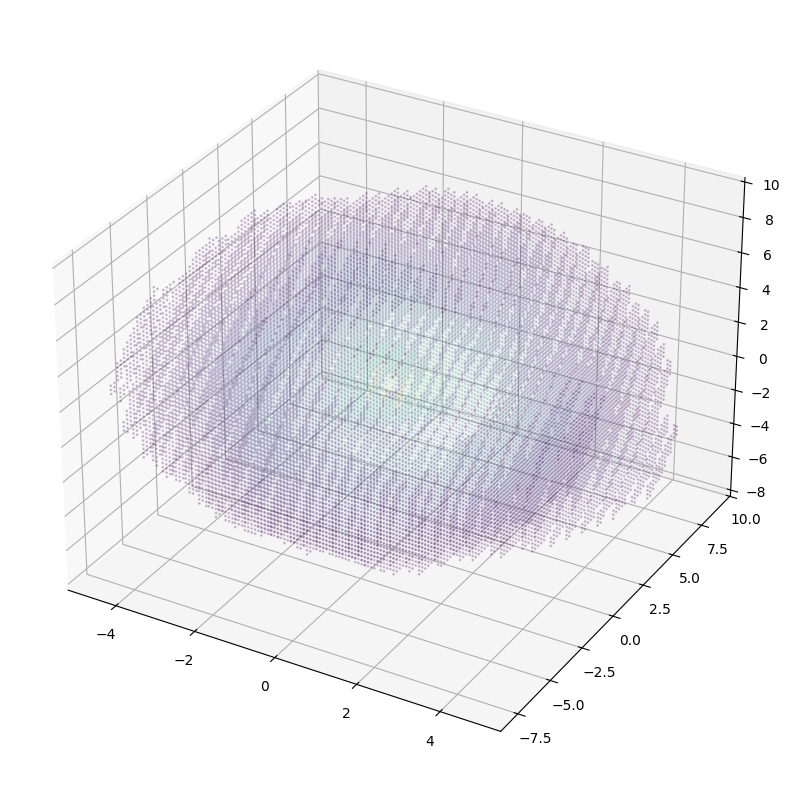

In [3]:

gal_number = 161

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

gas_name = '*gas*_' + str(gal_number) + '.hdf5'

gas_files = []
for filename in glob.glob(os.path.join(directory, gas_name)):
    gas_files.append(filename)


directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

stars_files = []
for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_number) + '.hdf5')):
    stars_files.append(filename)

dm_files = []
for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_number) + '.hdf5')):
    dm_files.append(filename)

gas_filename = gas_files[0]
print(gas_filename)
star_filename = stars_files[0]
dm_filename = dm_files[0]


from dynamics import load_all_data

star_data, dm_data, gas_data, mass_multiplier, length_multiplier, time_multiplier = load_all_data(star_filename, dm_filename, gas_filename, ozy_file)

positions = np.column_stack((gas_data['x'], gas_data['y'], gas_data['z']))
velocities = np.column_stack((gas_data['vx'], gas_data['vy'], gas_data['vz']))
masses = gas_data['mass']

total_mass = np.sum(masses)
print('Total mass of the gas particles: ', total_mass)


tot_ang_mom = np.cross(positions, velocities) * masses[:, np.newaxis]
total_angular_momentum = np.sum(tot_ang_mom, axis=0)
total_ang_mom_unit_v = total_angular_momentum/np.linalg.norm(total_angular_momentum)


plt.scatter(positions[:,0], positions[:,1], c = np.log10(masses))
plt.xlabel('X [Kpc]', fontsize = 12)
plt.ylabel('Y [Kpc]', fontsize = 12)
plt.show()

fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(15, 10))

ax.scatter(positions[:,0], positions[:,1], positions[:,2], c = np.log10(masses), s = 1, alpha = 0.2)
plt.show()

In [4]:
from dynamics import create_rotation_matrix

print(velocities)
print(positions)


rot_matrix = create_rotation_matrix(velocities, positions, masses, False)
                                    


[[-1.58170771e-16  1.12484122e-15  3.08069236e-15]
 [-1.96485852e-16  1.22450145e-15  3.05764618e-15]
 [-2.43658487e-16  1.34929546e-15  3.02956537e-15]
 ...
 [ 4.61591343e-17 -1.79558796e-15 -2.94414397e-15]
 [ 4.37739014e-17 -1.77386587e-15 -2.95503665e-15]
 [ 1.49168377e-17 -1.56589518e-15 -3.04732883e-15]] kpc/s
[[-4.55457413 -7.11574636  2.38410684]
 [-4.55457413 -7.11574636  2.62263974]
 [-4.55457413 -7.11574636  2.86117264]
 ...
 [ 4.748209    7.43476059 -3.34068278]
 [ 4.748209    7.43476059 -3.10214988]
 [ 4.748209    7.43476059 -2.86361697]]
[[-0.123009    0.47313473  0.8723602 ]
 [ 0.47313473  0.80066369 -0.36753393]
 [-0.8723602   0.36753393 -0.32234531]]


In [6]:
star_positions = np.column_stack((star_data['x'], star_data['y'], star_data['z']))
star_velocities = np.column_stack((star_data['vx'], star_data['vy'], star_data['vz']))
star_masses = star_data['mass']

tot_ang_mom = np.cross(star_positions, star_velocities) * star_masses[:, np.newaxis]
total_angular_momentum = np.sum(tot_ang_mom, axis=0)
star_total_ang_mom_unit_v = total_angular_momentum/np.linalg.norm(total_angular_momentum)


centroid = np.average(positions, axis=0, weights=masses)

# Compute the mass-weighted inertia tensor
I = np.zeros((3, 3))
for i in range(0, len(masses), 1000):
    r = positions[i]
    m = masses[i]
    I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(I)


# The eigenvector corresponding to the largest eigenvalue is the normal to the plane
gas_plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

# Plane equation: n.r = d
A, B, C = gas_plane_normal
D = -np.dot(gas_plane_normal, centroid)


# Generate grid for the plane
x_vals = np.linspace(min(positions[:, 0]), max(positions[:, 0]), 10)
y_vals = np.linspace(min(positions[:, 1]), max(positions[:, 1]), 10)
gas_X, gas_Y = np.meshgrid(x_vals, y_vals)

# Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
gas_Z = (-A * gas_X - B * gas_Y - D) / C

gas_plane_normal = gas_plane_normal/np.linalg.norm(gas_plane_normal)


centroid = np.average(star_positions, axis=0, weights=star_masses)

# Compute the mass-weighted inertia tensor
I = np.zeros((3, 3))
for i in range(0, len(star_masses), 1000):
    r = star_positions[i]
    m = star_masses[i]
    I += m * (np.dot(r, r) * np.eye(3) - np.outer(r, r))



# Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(I)


# The eigenvector corresponding to the largest eigenvalue is the normal to the plane
star_plane_normal = eigenvectors[:, 2]  # Largest eigenvalue

# Plane equation: n.r = d
A, B, C = star_plane_normal
D = -np.dot(star_plane_normal, centroid)


# Generate grid for the plane
x_vals = np.linspace(min(star_positions[:, 0]), max(star_positions[:, 0]), 10)
y_vals = np.linspace(min(star_positions[:, 1]), max(star_positions[:, 1]), 10)
star_X, star_Y = np.meshgrid(x_vals, y_vals)

# Solve for Z using Ax + By + Cz + D = 0 -> Z = (-A*X - B*Y - D) / C
star_Z = (-A * star_X - B * star_Y - D) / C

star_plane_normal = star_plane_normal/np.linalg.norm(star_plane_normal)





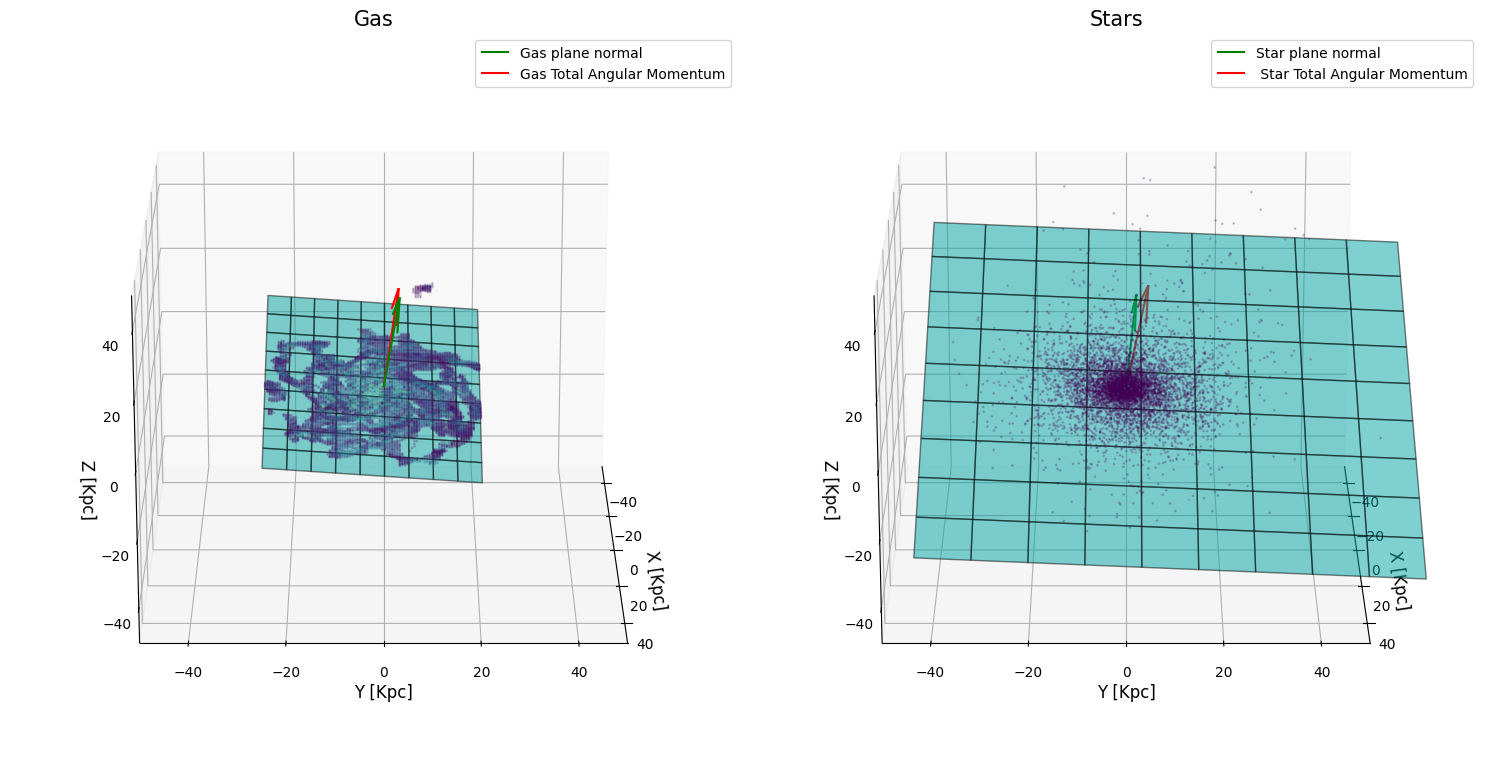

In [7]:
fig, ax = plt.subplots(1,2, subplot_kw={'projection': '3d'}, figsize=(15, 10))


# Plot the plane
ax[0].plot_surface(gas_X, gas_Y, gas_Z, alpha=0.5, color='cyan', edgecolor='k')

# Plot the plane
ax[1].plot_surface(star_X, star_Y, star_Z, alpha=0.5, color='cyan', edgecolor='k')

ax[0].scatter(positions[:,0], positions[:,1], positions[:,2], c = np.log10(masses), s = 1, alpha = 0.2)

ax[0].quiver(0, 0, 0, gas_plane_normal[0]*40, gas_plane_normal[1]*40, gas_plane_normal[2]*40, color='g', label = 'Gas plane normal')

ax[0].quiver(0, 0, 0, total_ang_mom_unit_v[0]*40, total_ang_mom_unit_v[1]*40, total_ang_mom_unit_v[2]*40, color='r', label="Gas Total Angular Momentum")

ax[1].scatter(star_positions[:,0][::1000], star_positions[:,1][::1000], star_positions[:,2][::1000], c = np.log10(star_masses[::1000]), s = 1, alpha = 0.2)

ax[1].quiver(0, 0, 0, star_plane_normal[0]*40, star_plane_normal[1]*40, star_plane_normal[2]*40, color='g', label = 'Star plane normal')

ax[1].quiver(0, 0, 0, star_total_ang_mom_unit_v[0]*40, star_total_ang_mom_unit_v[1]*40, star_total_ang_mom_unit_v[2]*40, color='r', label=" Star Total Angular Momentum")


ax[0].set_xlim(-50, 50)
ax[0].set_ylim(-50, 50)
ax[0].set_zlim(-50, 50)

ax[1].set_xlim(-50, 50)
ax[1].set_ylim(-50, 50)
ax[1].set_zlim(-50, 50)

ax[0].set_title('Gas', fontsize = 15)
ax[1].set_title('Stars', fontsize = 15)

ax[0].set_xlabel('X [Kpc]', fontsize = 12)
ax[0].set_ylabel('Y [Kpc]', fontsize = 12)
ax[0].set_zlabel('Z [Kpc]', fontsize = 12)

ax[1].set_xlabel('X [Kpc]', fontsize = 12)
ax[1].set_ylabel('Y [Kpc]', fontsize = 12)
ax[1].set_zlabel('Z [Kpc]', fontsize = 12)

ax[0].view_init(elev=20, azim=0)
ax[1].view_init(elev=20, azim=0)

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()



In [8]:
#Calculate angle between star plane normal and other three vectors

cos_theta = np.dot(star_plane_normal, total_ang_mom_unit_v)/(np.linalg.norm(star_plane_normal)*np.linalg.norm(total_ang_mom_unit_v))
theta = np.arccos(cos_theta)/2/np.pi*360
print('Angle between star plane normal and gas total angular momentum: ', theta)

cos_theta = np.dot(star_plane_normal, gas_plane_normal)/(np.linalg.norm(star_plane_normal)*np.linalg.norm(gas_plane_normal))
theta = np.arccos(cos_theta)/2/np.pi*360
print('Angle between star plane normal and gas plane normal: ', theta)

cos_theta = np.dot(star_plane_normal, star_total_ang_mom_unit_v)/(np.linalg.norm(star_plane_normal)*np.linalg.norm(star_total_ang_mom_unit_v))
theta = np.arccos(cos_theta)/2/np.pi*360
print('Angle between star plane normal and star total angular momentum: ', theta)

cos_theta = np.dot(gas_plane_normal, total_ang_mom_unit_v)/(np.linalg.norm(gas_plane_normal)*np.linalg.norm(total_ang_mom_unit_v))
theta = np.arccos(cos_theta)/2/np.pi*360
print('Angle between gas plane normal and gas total angular momentum: ', theta)

Angle between star plane normal and gas total angular momentum:  3.6397257114438424
Angle between star plane normal and gas plane normal:  2.153092070920903
Angle between star plane normal and star total angular momentum:  6.2515057688600235
Angle between gas plane normal and gas total angular momentum:  4.609137275415067


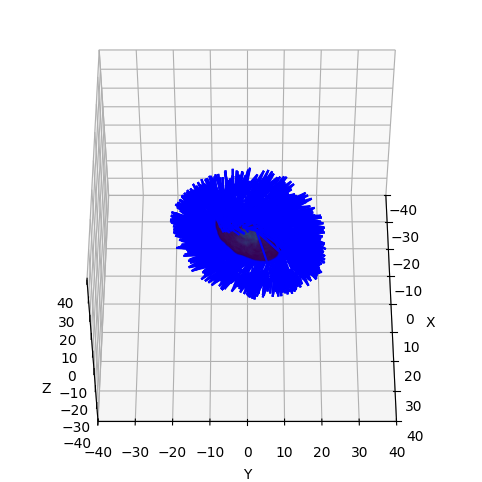

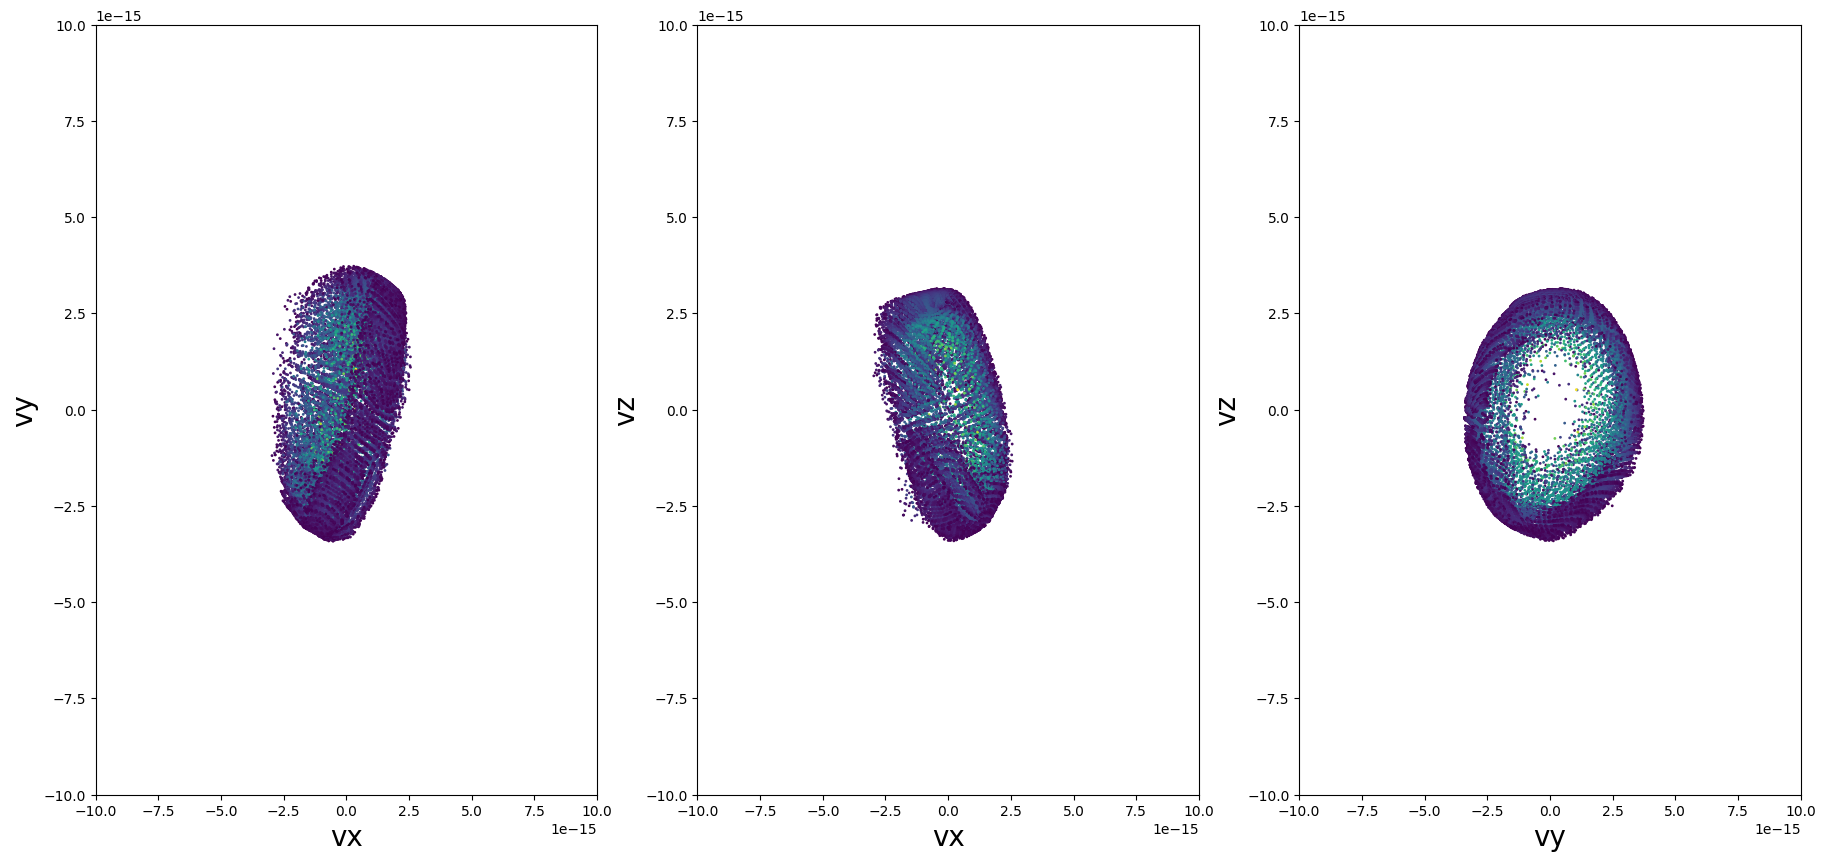

In [5]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 6))

ax.scatter(positions[:,0], positions[:,1], positions[:,2], c = np.log10(masses), alpha = 0.05)

ax.quiver(0, 0, 0, total_ang_mom_unit_v[0]*20, total_ang_mom_unit_v[1]*20, total_ang_mom_unit_v[2]*20, color='r', label="Total Angular Momentum")

for i in range(0, len(velocities), 50):
    vel = velocities[i]/np.linalg.norm(velocities[i])
    pos = positions[i]
    ax.quiver(pos[0], pos[1], pos[2], vel[0]*20, vel[1]*20, vel[2]*20, color='b')


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim(-40,40)
ax.set_ylim(-40,40)
ax.set_zlim(-40,40)

ax.view_init(elev=50, azim=0)

plt.show()

fig, ax = plt.subplots(1, 3, figsize = (22,10))

ax[0].scatter(velocities[:,0], velocities[:,1], c = np.log10(masses), s = 1)
ax[0].set_xlabel('vx', fontsize = 20)
ax[0].set_ylabel('vy', fontsize = 20)
ax[0].set_xlim(-10e-15, 10e-15)
ax[0].set_ylim(-10e-15, 10e-15)

ax[1].scatter(velocities[:,0], velocities[:,2], c = np.log10(masses), s = 1)
ax[1].set_xlabel('vx', fontsize = 20)
ax[1].set_ylabel('vz', fontsize = 20)
ax[1].set_xlim(-10e-15, 10e-15)
ax[1].set_ylim(-10e-15, 10e-15)

ax[2].scatter(velocities[:,1], velocities[:,2], c = np.log10(masses), s = 1)
ax[2].set_xlabel('vy', fontsize = 20)
ax[2].set_ylabel('vz', fontsize = 20)
ax[2].set_xlim(-10e-15, 10e-15)
ax[2].set_ylim(-10e-15, 10e-15)

plt.show()



In [6]:
from dynamics import create_rotation_matrix_plane

plane_rot_mat = create_rotation_matrix_plane(positions, masses, velocities)

velocities_rot= np.dot(plane_rot_mat, velocities[:][:].T).T
positions_rot = np.dot(plane_rot_mat, positions[:][:].T).T

ang_mom = np.cross(positions_rot, velocities_rot) * masses[:, np.newaxis]
total_ang_mom = np.sum(ang_mom, axis=0)
total_ang_mom_unit_v = total_ang_mom/np.linalg.norm(total_ang_mom)
print('Total angular momentum: ', total_ang_mom_unit_v)


Total angular momentum:  [ 0.01218017 -0.00302685  0.99992124] dimensionless


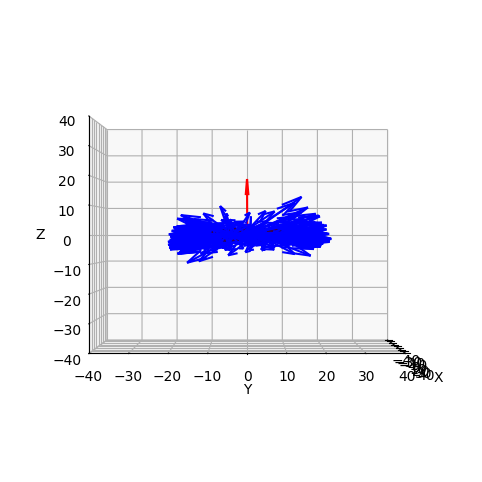

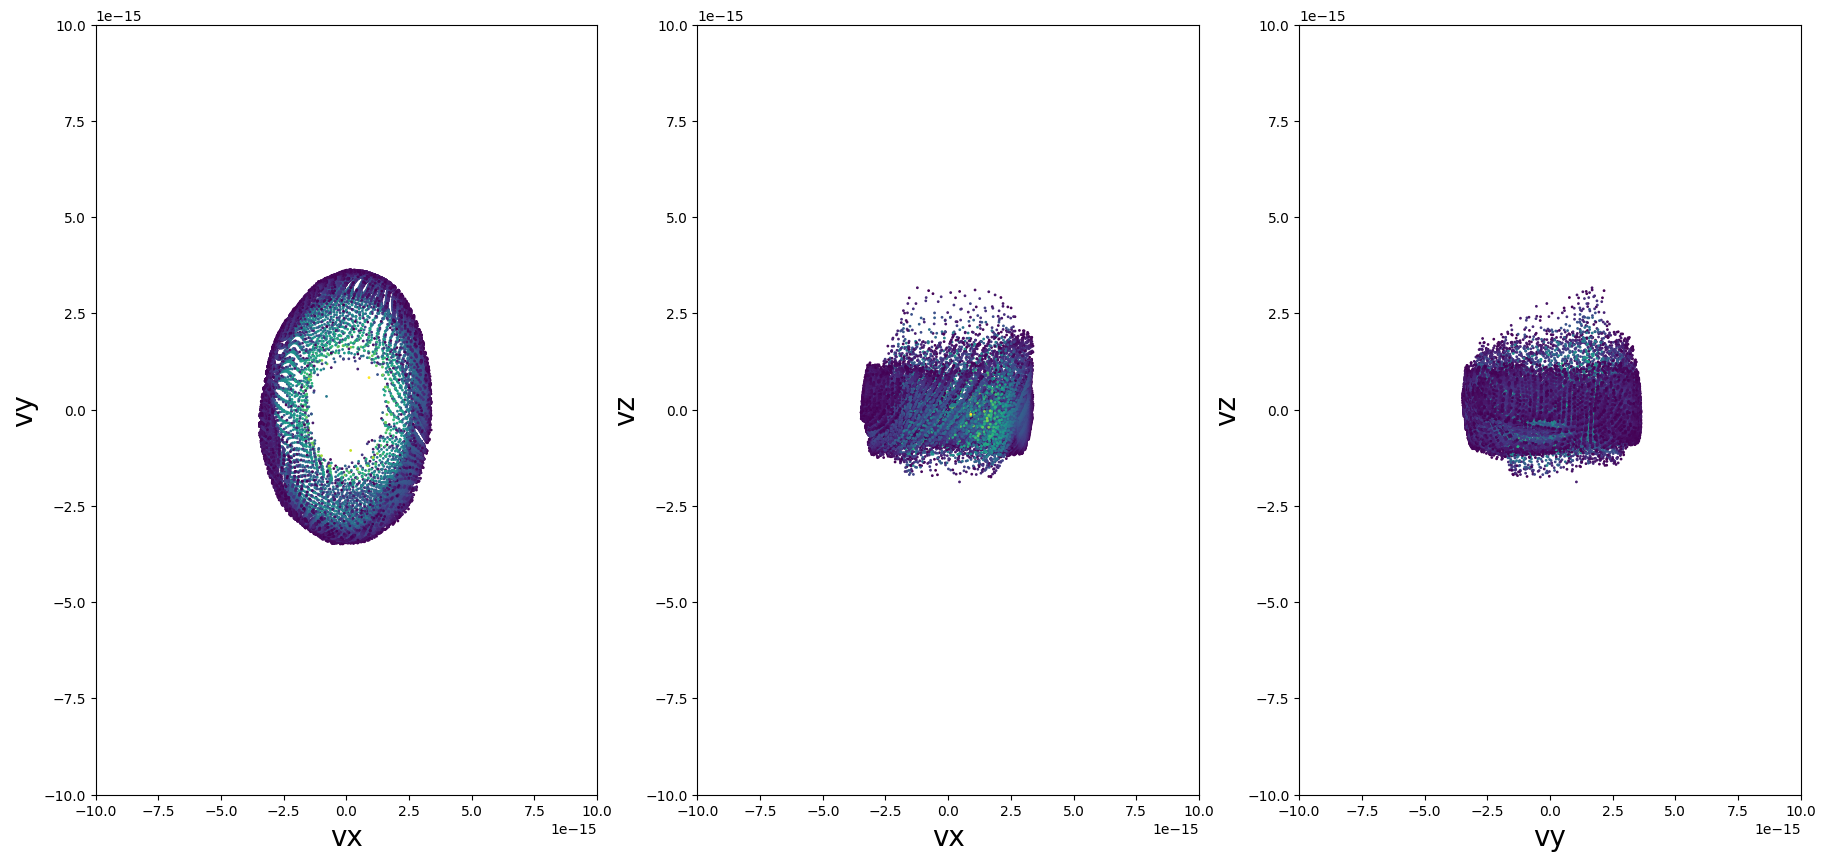

In [7]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 6))

ax.scatter(positions_rot[:,0], positions_rot[:,1], positions_rot[:,2], c = np.log10(masses), alpha = 0.05)

ax.quiver(0, 0, 0, total_ang_mom_unit_v[0]*20, total_ang_mom_unit_v[1]*20, total_ang_mom_unit_v[2]*20, color='r', label="Total Angular Momentum")

for i in range(0, len(velocities_rot), 100):
    rotated_vel = velocities_rot[i]/np.linalg.norm(velocities_rot[i])
    rotated_pos = positions_rot[i]
    ax.quiver(rotated_pos[0], rotated_pos[1], rotated_pos[2], rotated_vel[0]*20, rotated_vel[1]*20, rotated_vel[2]*20, color='b')


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim(-40,40)
ax.set_ylim(-40,40)
ax.set_zlim(-40,40)

ax.view_init(elev=0, azim=0)

plt.show()

fig, ax = plt.subplots(1, 3, figsize = (22,10))

ax[0].scatter(velocities_rot[:,0], velocities_rot[:,1], c = np.log10(masses), s = 1)
ax[0].set_xlabel('vx', fontsize = 20)
ax[0].set_ylabel('vy', fontsize = 20)
ax[0].set_xlim(-10e-15, 10e-15)
ax[0].set_ylim(-10e-15, 10e-15)

ax[1].scatter(velocities_rot[:,0], velocities_rot[:,2], c = np.log10(masses), s = 1)
ax[1].set_xlabel('vx', fontsize = 20)
ax[1].set_ylabel('vz', fontsize = 20)
ax[1].set_xlim(-10e-15, 10e-15)
ax[1].set_ylim(-10e-15, 10e-15)

ax[2].scatter(velocities_rot[:,1], velocities_rot[:,2], c = np.log10(masses), s = 1)
ax[2].set_xlabel('vy', fontsize = 20)
ax[2].set_ylabel('vz', fontsize = 20)
ax[2].set_xlim(-10e-15, 10e-15)
ax[2].set_ylim(-10e-15, 10e-15)

plt.show()



In [8]:


def matrix_of_rotation(v1, v2):
    cos = np.dot(v1, v2)
    cross = np.cross(v1, v2)
    sin = np.sum(cross**2)**0.5
    cross = cross/sin
    rotation_matrix = np.array([[cos + cross[0]**2*(1-cos), cross[0]*cross[1]*(1-cos) - cross[2]*sin, cross[0]*cross[2]*(1-cos) + cross[1]*sin],
                                [cross[1]*cross[0]*(1-cos) + cross[2]*sin, cos + cross[1]**2*(1-cos), cross[1]*cross[2]*(1-cos) - cross[0]*sin],
                                [cross[2]*cross[0]*(1-cos) - cross[1]*sin, cross[2]*cross[1]*(1-cos) + cross[0]*sin, cos + cross[2]**2*(1-cos)]])
    #Rotation matrix found from wikipedia
    return rotation_matrix

v1 = total_ang_mom_unit_v
v2 = np.array([0,0,1])

rotation_matrix = matrix_of_rotation(v1, v2)

print(rotation_matrix**2)

[[9.99851643e-01 3.39830534e-10 1.48356593e-04]
 [3.39830534e-10 9.99990838e-01 9.16181106e-06]
 [1.48356593e-04 9.16181106e-06 9.99842482e-01]]


In [9]:
velocities_rot_rot = np.dot(rotation_matrix, velocities_rot.T).T
positions_rot = np.dot(rotation_matrix, positions_rot.T).T

new_ang_mom = np.cross(positions_rot, velocities_rot_rot) * masses[:, np.newaxis]
new_total_ang_mom = np.sum(new_ang_mom, axis=0)
new_total_ang_mom_unit_v = new_total_ang_mom/np.linalg.norm(new_total_ang_mom)

print(new_total_ang_mom_unit_v)
print(new_total_ang_mom)

[ 6.62442489e-17 -2.53175051e-17  1.00000000e+00] dimensionless
[ 2.05450985e-21 -7.85201196e-22  3.10141617e-05] Msun/(kpc**2*s)


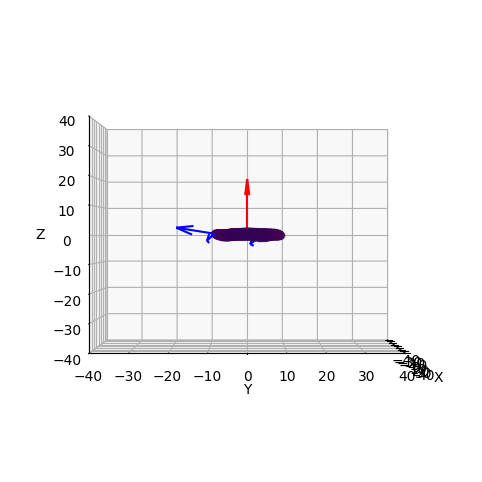

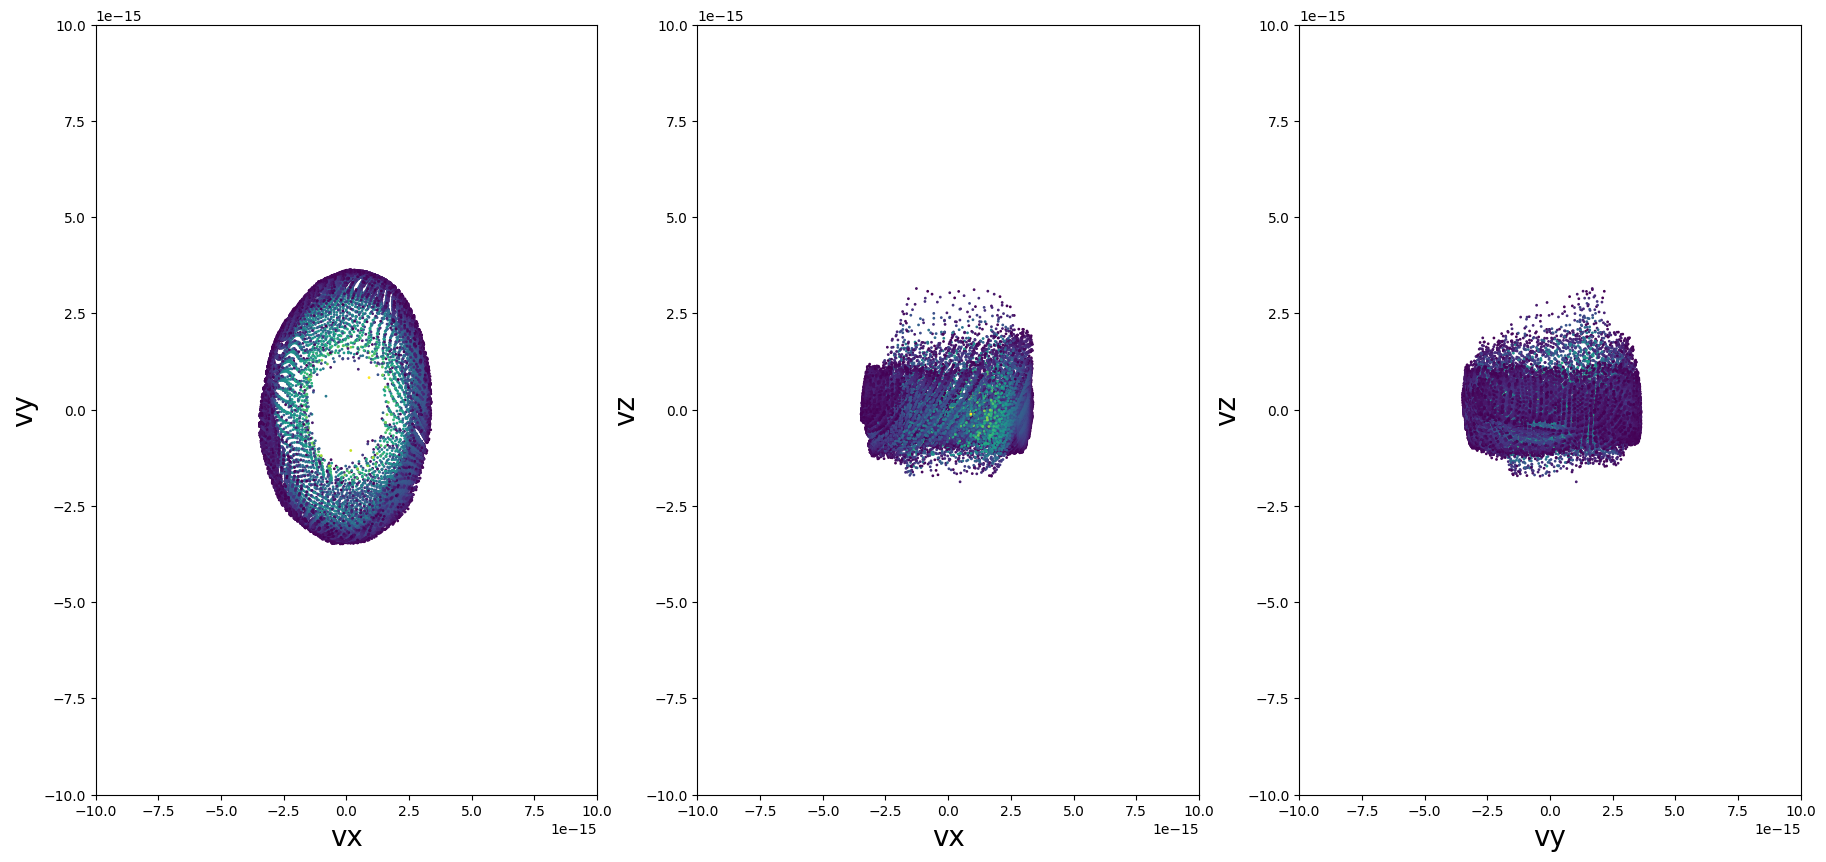

In [12]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 6))

ax.scatter(positions_rot[:,0], positions_rot[:,1], positions_rot[:,2], c = np.log10(masses), alpha = 0.05)

ax.quiver(0, 0, 0, new_total_ang_mom_unit_v[0]*20, new_total_ang_mom_unit_v[1]*20, new_total_ang_mom_unit_v[2]*20, color='r', label="Total Angular Momentum")

for i in range(0, len(velocities_rot_rot), 10000):
    rotated_vel = velocities_rot_rot[i]/np.linalg.norm(velocities_rot_rot[i])
    rotated_pos = positions_rot[i]
    ax.quiver(rotated_pos[0], rotated_pos[1], rotated_pos[2], rotated_vel[0]*20, rotated_vel[1]*20, rotated_vel[2]*20, color='b')


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim(-40,40)
ax.set_ylim(-40,40)
ax.set_zlim(-40,40)

ax.view_init(elev=0, azim=0)

plt.show()

fig, ax = plt.subplots(1, 3, figsize = (22,10))

ax[0].scatter(velocities_rot_rot[:,0], velocities_rot_rot[:,1], c = np.log10(masses), s = 1)
ax[0].set_xlabel('vx', fontsize = 20)
ax[0].set_ylabel('vy', fontsize = 20)
ax[0].set_xlim(-10e-15, 10e-15)
ax[0].set_ylim(-10e-15, 10e-15)

ax[1].scatter(velocities_rot_rot[:,0], velocities_rot_rot[:,2], c = np.log10(masses), s = 1)
ax[1].set_xlabel('vx', fontsize = 20)
ax[1].set_ylabel('vz', fontsize = 20)
ax[1].set_xlim(-10e-15, 10e-15)
ax[1].set_ylim(-10e-15, 10e-15)

ax[2].scatter(velocities_rot_rot[:,1], velocities_rot_rot[:,2], c = np.log10(masses), s = 1)
ax[2].set_xlabel('vy', fontsize = 20)
ax[2].set_ylabel('vz', fontsize = 20)
ax[2].set_xlim(-10e-15, 10e-15)
ax[2].set_ylim(-10e-15, 10e-15)

plt.show()


In [15]:

def cartesian_to_cylindrical_points(x, y, z):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)
    z = z
    return np.array([r, theta, z]).T

cylindrical_points = cartesian_to_cylindrical_points(positions_rot[:,0], positions_rot[:,1], positions_rot[:,2])

cylindrical_shells = cylindrical_points[:,0]

mapping = np.argsort(cylindrical_shells)

cylindrical_shells = cylindrical_shells[mapping]

masses_sorted = masses[mapping]

total_mass = np.sum(masses_sorted)

cum_mass = np.cumsum(masses_sorted)

r_half_index = np.where(cum_mass >= total_mass/2)[0][0]

print(r_half_index)

r_half = cylindrical_shells[r_half_index]

print(r_half)


4739
12.129995533489929


In [21]:
gals = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies.txt')

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]

from dynamics import load_gas_data

nothing = []

for gal in gals:

    print(gal)

    gal_number = int(gal)

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

    gas_name = '*gas*_' + str(gal_number) + '.hdf5'

    gas_files = []
    for filename in glob.glob(os.path.join(directory, gas_name)):
        gas_files.append(filename)

    gas_filename = gas_files[0]

    positions, masses, densities, velocities = load_gas_data(gas_filename, ozy_file)

    if len(positions) == 0:
        nothing.append(gal)
    


1.0
2.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
16.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
27.0
29.0
31.0
34.0
36.0
37.0
38.0
39.0
41.0
47.0
49.0
50.0
51.0
52.0
53.0
54.0
57.0
58.0
61.0
64.0
65.0
66.0
69.0
71.0
72.0
74.0
77.0
80.0
83.0
84.0
86.0
89.0
90.0
92.0
95.0
96.0
100.0
102.0
106.0
107.0
108.0
110.0
112.0
113.0
114.0
116.0
117.0
120.0
123.0
124.0
128.0
132.0
134.0
137.0
141.0
143.0
144.0
147.0
148.0
149.0
152.0
155.0
156.0
159.0
161.0
162.0
165.0
166.0
168.0
169.0
170.0
177.0
179.0
182.0
184.0
185.0
187.0
188.0
189.0
191.0
193.0
197.0
198.0
200.0
212.0
220.0
228.0
233.0
241.0
243.0
246.0
247.0
253.0
255.0
256.0
258.0
259.0
260.0
261.0
262.0
280.0
290.0
312.0
322.0
328.0
329.0
339.0
352.0
355.0
362.0
375.0
378.0
379.0
382.0
383.0
387.0
388.0
391.0
395.0
396.0
397.0
399.0
407.0
413.0
427.0
430.0
433.0
439.0
456.0
458.0
467.0
475.0
478.0
480.0
488.0
493.0
494.0
496.0
498.0
499.0
504.0
508.0
516.0
535.0
539.0
545.0
547.0
561.0
563.0
570.0
575.0
583.0
594.0
598.0
608.0
610.0
617.0
619.

In [22]:
print(len(nothing))
print(nothing)

26
[np.float64(37.0), np.float64(58.0), np.float64(65.0), np.float64(84.0), np.float64(86.0), np.float64(144.0), np.float64(148.0), np.float64(168.0), np.float64(170.0), np.float64(212.0), np.float64(355.0), np.float64(399.0), np.float64(467.0), np.float64(622.0), np.float64(660.0), np.float64(664.0), np.float64(666.0), np.float64(685.0), np.float64(687.0), np.float64(793.0), np.float64(825.0), np.float64(873.0), np.float64(886.0), np.float64(934.0), np.float64(1010.0), np.float64(1049.0)]
